In [17]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import spiceypy as spy

In [18]:
tabla, jd, X = pc.consulta_horizons(
    id='Apophis',
    location='@SSB',
    epochs='2026-04-20'
)
X

array([-4.54615645e+10,  1.46498906e+11, -8.91205586e+09, -2.72244445e+04,
       -4.00763765e+03, -4.30333986e+02])

In [19]:
rvec=X[:3]
r = np.linalg.norm(rvec)
vvec=X[3:]
v = np.linalg.norm(vvec)
rvec, vvec, r, v

(array([-4.54615645e+10,  1.46498906e+11, -8.91205586e+09]),
 array([-27224.44453608,  -4007.63764628,   -430.33398559]),
 np.float64(153649302107.4954),
 np.float64(27521.20504522595))

Para la determinación de los elementos orbitales necesito estos vectores: $\vec r, \vec v, \vec h, \vec e, \vec n$

In [20]:
#MARE
hvec = np.cross(rvec, vvec)
h = np.linalg.norm(hvec)

#Vector de Laplace
mu = pc.constantes.mu_sun  #Aproximación que no me permiten en la UdeA, pero voy a ahcer porque no tengo tiempo :v
evec = np.cross(vvec, hvec) / mu - rvec / r
e = np.linalg.norm(evec)

#Vector de nodos
nvec = np.cross([0, 0, 1], hvec)
n = np.linalg.norm(nvec)


Ahora a determinar los elementos orbitales $(p, e, I, \Omega, \omega, f)$

In [21]:
rad = 180 / np.pi #Factor de convercion a grados

p = h**2 / mu
e = e #Es la magntud de evec
I = np.arccos(hvec[2] / h)
omegap = np.arccos(nvec @ evec / (n * e)) 
omega = omegap if evec[2] > 0 else 2*np.pi - omegap

Omegap = np.arccos(nvec @ [1,0,0] / n)
Omega = Omegap if nvec[1] > 0 else 2*np.pi - Omegap



In [22]:
fp = np.arccos(rvec @ evec / (r * e))
f = fp if rvec @ vvec / r > 0 else 2*np.pi - fp
f*rad

np.float64(137.0639111789069)

In [23]:
def elementos_orbitales_desde_rv(rvec, vvec, mu, tol=1e-12):
    rvec = np.asarray(rvec, dtype=float)
    vvec = np.asarray(vvec, dtype=float)

    r = np.linalg.norm(rvec)
    v = np.linalg.norm(vvec)

    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)

    kvec = np.array([0.0, 0.0, 1.0])
    nvec = np.cross(kvec, hvec)
    n = np.linalg.norm(nvec)

    evec = np.cross(vvec, hvec) / mu - rvec / r
    e = np.linalg.norm(evec)

    p = h**2 / mu
    I = np.arccos(np.clip(hvec[2] / h, -1.0, 1.0))

    # Longitud del nodo ascendente
    if n > tol:
        Omega = np.mod(np.arctan2(nvec[1], nvec[0]), 2 * np.pi)
    else:
        Omega = 0.0

    # Argumento del periastro
    if e > tol and n > tol:
        sin_omega = np.dot(np.cross(nvec, evec), hvec) / (n * h * e)
        cos_omega = np.dot(nvec, evec) / (n * e)
        omega = np.mod(np.arctan2(sin_omega, cos_omega), 2 * np.pi)
    elif e > tol:
        # órbita ecuatorial: usar longitud del periastro
        omega = np.mod(np.arctan2(evec[1], evec[0]), 2 * np.pi)
    else:
        omega = 0.0

    # Anomalía verdadera
    if e > tol:
        sin_f = np.dot(np.cross(evec, rvec), hvec) / (e * h * r)
        cos_f = np.dot(evec, rvec) / (e * r)
        f = np.mod(np.arctan2(sin_f, cos_f), 2 * np.pi)
    elif n > tol:
        # órbita circular inclinada: usar argumento de latitud
        sin_u = np.dot(np.cross(nvec, rvec), hvec) / (n * h * r)
        cos_u = np.dot(nvec, rvec) / (n * r)
        f = np.mod(np.arctan2(sin_u, cos_u), 2 * np.pi)
    else:
        # órbita circular ecuatorial: usar longitud verdadera
        f = np.mod(np.arctan2(rvec[1], rvec[0]), 2 * np.pi)

    return p, e, I, Omega, omega, f


# Uso con tus variables actuales:
p, e, I, Omega, omega, f = elementos_orbitales_desde_rv(rvec, vvec, mu)
p, e, I, Omega, omega, f

(np.float64(131509557547.50772),
 np.float64(0.19681731768435504),
 np.float64(0.05842629206271991),
 np.float64(3.5583973880178488),
 np.float64(2.204461460912189),
 np.float64(2.392216535732988))

In [24]:
p, e, I*rad, Omega*rad, omega*rad, f*rad

(np.float64(131509557547.50772),
 np.float64(0.19681731768435504),
 np.float64(3.3475799477925516),
 np.float64(203.8811521637987),
 np.float64(126.30633780951213),
 np.float64(137.0639111789069))

# La órbita del Sol

In [33]:
tabla, jds, Xs = pc.consulta_horizons(
    id='Sun',
    location='@SSB',
    epochs=dict(start='2026-04-20', stop='2038-04-20', step='180d')
)
Xs = np.array(Xs)

(np.float64(-842032241.6442443),
 np.float64(626737755.2459141),
 np.float64(-1214816946.0738049),
 np.float64(270112377.0375037))

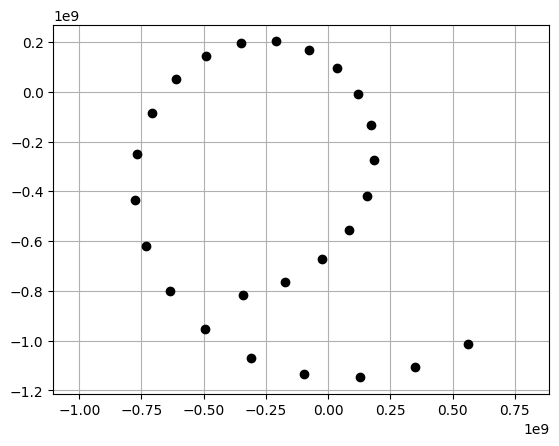

In [41]:
mu = pc.constantes.mu_sun + pc.constantes.mu_jupiter + pc.constantes.mu_saturn  
Es = np.zeros((len(jds), 6))

for i, jd in enumerate(jds):
    rvec = Xs[i, :3]
    vvec = Xs[i, 3:]
    p, e, I, Omega, omega, f = elementos_orbitales_desde_rv(rvec, vvec, mu)
    Es[i, :] = [p, e, I, Omega, omega, f]
    plt.plot(rvec[0], rvec[1], 'ko')
plt.grid()
plt.axis('equal')



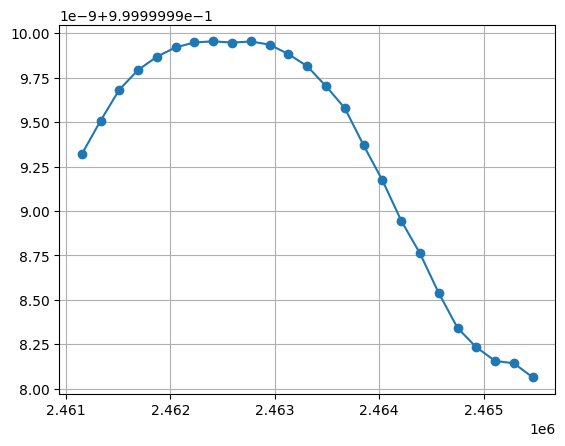

In [44]:
plt.plot(jds, Es[:, 1], 'o-')
plt.grid()


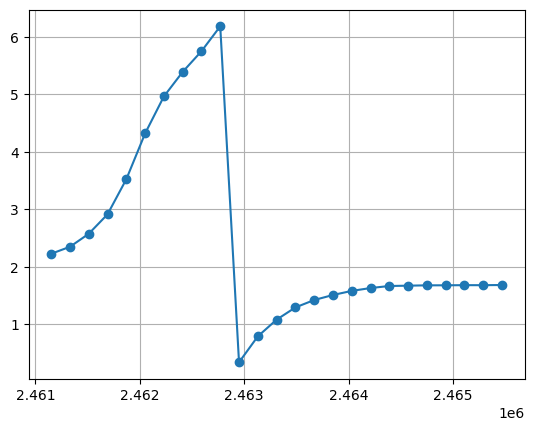

In [45]:
plt.plot(jds, Es[:, 3], 'o-')
plt.grid()

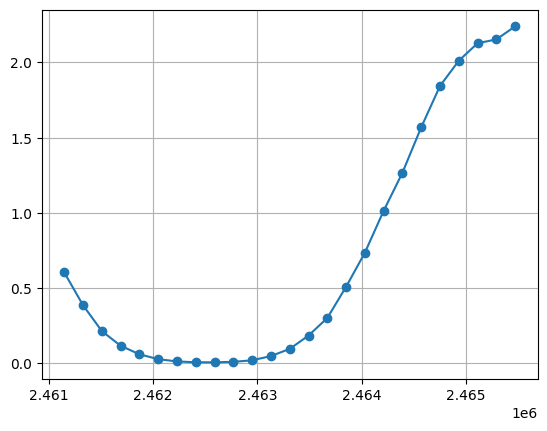

In [46]:
plt.plot(jds, Es[:, 0], 'o-')
plt.grid()